# Setup Spark Session & Logging

In [1]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window

import logging
import matplotlib.pyplot as plt

# Logging Configuration
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("NYC_JOBS_PIPELINE")

spark = (
    SparkSession.builder
    .appName("nyc-jobs-assessment-v2.3")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

logger.info("Spark session started successfully")

INFO:NYC_JOBS_PIPELINE:Spark session started successfully


# Read Dataset

In [2]:
DATA_PATH = "/dataset/nyc-jobs.csv" 

df_raw = spark.read.csv(DATA_PATH, header=True, inferSchema=False)

print("Total Raw Records:", df_raw.count())
df_raw.printSchema()

Total Raw Records: 2946
root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: string (nullable = true)
 |-- Salary Range To: string (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable =

# Quick Data Validation

In [3]:
df_raw.columns

df_raw.select("Salary Frequency").distinct().show()

df_raw.select("Posting Date").show(5, False)

+----------------+
|Salary Frequency|
+----------------+
|          Annual|
|           Daily|
|          Hourly|
+----------------+

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Posting Date                                                                                                                                                                                                                                                                                                                                                                                                    |
+-----------------------------------------------------------

# Data Processing & Feature Engineering

### Features Added:

1.Salary normalization to annual

2.Higher degree flag

3.Mid salary

4.Posting year extraction

5.Skill extraction

6.Salary range validation

In [4]:
def preprocess_jobs(df):
    
    logger.info("Starting preprocessing...")
    
    df_clean = (
        df
        # Cast salary columns
        .withColumn("salary_from", col("Salary Range From").cast(DoubleType()))
        .withColumn("salary_to", col("Salary Range To").cast(DoubleType()))
        
        # Remove invalid salary rows
        .filter(
            col("salary_from").isNotNull() &
            col("salary_to").isNotNull() &
            (col("salary_to") >= col("salary_from"))
        )
        
        # Normalize Salary to Annual
        .withColumn(
            "annual_salary_from",
            when(col("Salary Frequency") == "Annual", col("salary_from"))
            .when(col("Salary Frequency") == "Hourly", col("salary_from") * 2080)
            .when(col("Salary Frequency") == "Daily", col("salary_from") * 260)
        )
        .withColumn(
            "annual_salary_to",
            when(col("Salary Frequency") == "Annual", col("salary_to"))
            .when(col("Salary Frequency") == "Hourly", col("salary_to") * 2080)
            .when(col("Salary Frequency") == "Daily", col("salary_to") * 260)
        )
        
        # Mid Salary Feature
        .withColumn(
            "mid_salary",
            (col("annual_salary_from") + col("annual_salary_to")) / 2
        )
        
        # Correct ISO Date Parsing
        .withColumn(
            "posting_ts",
            to_timestamp(col("Posting Date"))
        )
        .withColumn("posting_year", year(col("posting_ts")))
        
        # Higher Degree Feature
        .withColumn(
            "higher_degree_flag",
            when(
                lower(col("Minimum Qual Requirements")).rlike("master|phd|doctor"),
                1
            ).otherwise(0)
        )
        
        # Skill Extraction (basic keywords)
        .withColumn(
            "has_python",
            when(lower(col("Preferred Skills")).rlike("python"), 1).otherwise(0)
        )
        .withColumn(
            "has_sql",
            when(lower(col("Preferred Skills")).rlike("sql"), 1).otherwise(0)
        )
        .withColumn(
            "has_spark",
            when(lower(col("Preferred Skills")).rlike("spark"), 1).otherwise(0)
        )
    )
    
    logger.info("Preprocessing completed")
    return df_clean

### Apply Processing with Caching strategy

In [5]:
df_processed = preprocess_jobs(df_raw)

df_processed.cache()

print("Processed Records:", df_processed.count())

INFO:NYC_JOBS_PIPELINE:Starting preprocessing...
INFO:NYC_JOBS_PIPELINE:Preprocessing completed


Processed Records: 2946


# Data Quality Summary Table

In [6]:
dq_summary = df_processed.select([
    count("*").alias("total_records"),
    count("annual_salary_from").alias("valid_salary_from"),
    count("annual_salary_to").alias("valid_salary_to"),
    count("posting_ts").alias("valid_posting_dates")
])

dq_summary.show()

+-------------+-----------------+---------------+-------------------+
|total_records|valid_salary_from|valid_salary_to|valid_posting_dates|
+-------------+-----------------+---------------+-------------------+
|         2946|             2946|           2946|               1380|
+-------------+-----------------+---------------+-------------------+



In [7]:
# Additional Processing Validation

print("Additional Validation Checks")

# 1. Check annual salary normalization
df_processed.select(
    "Salary Frequency",
    "salary_from",
    "salary_to",
    "annual_salary_from",
    "annual_salary_to",
    "mid_salary"
).show(5, False)

# 2. Ensure no negative or inverted salary ranges
invalid_salary_ranges = df_processed.filter(
    col("annual_salary_to") < col("annual_salary_from")
).count()

print("Invalid salary ranges (should be 0):", invalid_salary_ranges)

# 3. Validate higher degree flag distribution
df_processed.groupBy("higher_degree_flag").count().show()

# 4. Validate skill extraction
df_processed.select("has_python", "has_sql", "has_spark").groupBy(
    "has_python", "has_sql", "has_spark"
).count().show()

# 5. Validate posting_year distribution
df_processed.groupBy("posting_year").count().orderBy("posting_year").show()

Additional Validation Checks
+----------------+-----------+---------+------------------+----------------+----------+
|Salary Frequency|salary_from|salary_to|annual_salary_from|annual_salary_to|mid_salary|
+----------------+-----------+---------+------------------+----------------+----------+
|Annual          |42405.0    |65485.0  |42405.0           |65485.0         |53945.0   |
|Annual          |60740.0    |162014.0 |60740.0           |162014.0        |111377.0  |
|Annual          |51907.68   |54580.32 |51907.68          |54580.32        |53244.0   |
|Annual          |51907.68   |54580.32 |51907.68          |54580.32        |53244.0   |
|Hourly          |35.0       |35.0     |72800.0           |72800.0         |72800.0   |
+----------------+-----------+---------+------------------+----------------+----------+
only showing top 5 rows

Invalid salary ranges (should be 0): 0
+------------------+-----+
|higher_degree_flag|count|
+------------------+-----+
|                 1|  726|
|      

# KPI Analysis

## KPI 1: Top 10 Job Categories

In [8]:
kpi1 = (
    df_processed.groupBy("Job Category")
    .count()
    .orderBy(desc("count"))
)

kpi1.show(10, False)

+-----------------------------------------+-----+
|Job Category                             |count|
+-----------------------------------------+-----+
|Engineering, Architecture, & Planning    |504  |
|Technology, Data & Innovation            |313  |
|Legal Affairs                            |226  |
|Public Safety, Inspections, & Enforcement|182  |
|Building Operations & Maintenance        |181  |
|Finance, Accounting, & Procurement       |169  |
|Administration & Human Resources         |134  |
|Constituent Services & Community Programs|129  |
|Health                                   |125  |
|Policy, Research & Analysis              |124  |
+-----------------------------------------+-----+
only showing top 10 rows



### Visualization

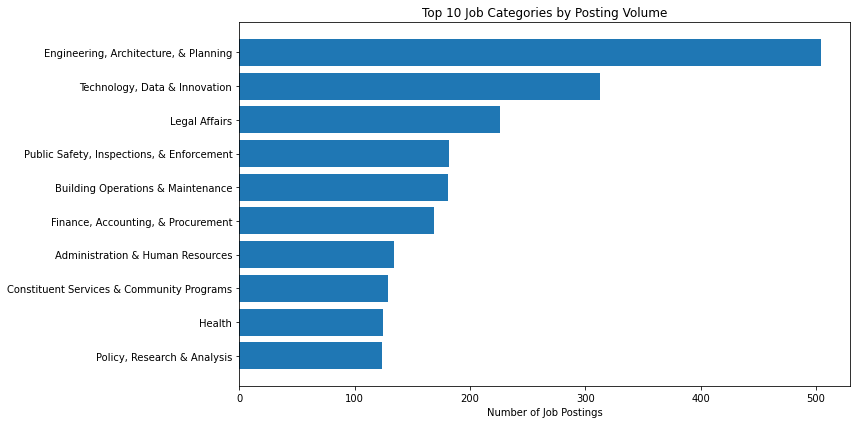

In [9]:
top10 = kpi1.limit(10).toPandas()

plt.figure(figsize=(12,6))
plt.barh(top10["Job Category"], top10["count"])
plt.xlabel("Number of Job Postings")
plt.title("Top 10 Job Categories by Posting Volume")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## KPI 2: Salary Distribution per Job Category

In [10]:
kpi2 = (
    df_processed.groupBy("Job Category")
    .agg(
        avg("annual_salary_from").alias("avg_salary_from"),
        avg("annual_salary_to").alias("avg_salary_to"),
        avg("mid_salary").alias("avg_mid_salary")
    )
    .orderBy(desc("avg_mid_salary"))
)

kpi2.show(10, False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+------------------+------------------+
|Job Category                                                                                                                                                                                             |avg_salary_from   |avg_salary_to     |avg_mid_salary    |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+------------------+------------------+
|Administration & Human Resources Finance, Accounting, & Procurement Building Operations & Maintenance                                                                                                    |218587.0      

## KPI 3: Correlation Between Higher Degree & Salary

In [11]:
kpi3 = (
    df_processed.groupBy("higher_degree_flag")
    .agg(avg("mid_salary").alias("avg_salary"))
)

kpi3.show()

+------------------+-----------------+
|higher_degree_flag|       avg_salary|
+------------------+-----------------+
|                 1|86118.47646280992|
|                 0|74886.67614414415|
+------------------+-----------------+



In [12]:
# Additional Statistical Validation
correlation_value = df_processed.stat.corr("higher_degree_flag", "mid_salary")
print("Correlation between Higher Degree and Salary:", correlation_value)

Correlation between Higher Degree and Salary: 0.1804615240515595


## KPI 4: Highest Salary Job per Agency

In [13]:
window_spec = Window.partitionBy("Agency").orderBy(desc("annual_salary_to"))

kpi4 = (
    df_processed
    .withColumn("rn", row_number().over(window_spec))
    .filter(col("rn") == 1)
    .select("Agency", "Business Title", "annual_salary_to")
)

kpi4.show(10, False)

+------------------------------+----------------------------------------------------+----------------+
|Agency                        |Business Title                                      |annual_salary_to|
+------------------------------+----------------------------------------------------+----------------+
|LANDMARKS PRESERVATION COMM   |LANDMARKS PRESERVATIONIST, PRESERVATION DEPT        |64297.0         |
|OFFICE OF COLLECTIVE BARGAININ|COLLEGE AIDE - CLERICAL                             |21548.8         |
|FIRE DEPARTMENT               |Senior Enterprise Applications Integration Developer|144929.0        |
|ADMIN FOR CHILDREN'S SVCS     |Director of Technical  Support                      |156829.0        |
|MANHATTAN COMMUNITY BOARD #8  |Community Assistant                                 |39520.0         |
|TAX COMMISSION                |CITY ASSESSOR                                       |90177.0         |
|HRA/DEPT OF SOCIAL SERVICES   |EXECUTIVE DIRECTOR, SERVER INFRASTRUCTURE

## KPI 5: Avg Salary per Agency (Last 2 Years in Dataset)

In [14]:
max_year = df_processed.agg({"posting_year": "max"}).collect()[0][0]

df_recent = df_processed.filter(
    col("posting_year") >= (max_year - 1)
)

kpi5 = (
    df_recent.groupBy("Agency")
    .agg(avg("mid_salary").alias("avg_recent_salary"))
    .orderBy(desc("avg_recent_salary"))
)

kpi5.show(10, False)

+------------------------------+-----------------+
|Agency                        |avg_recent_salary|
+------------------------------+-----------------+
|CONFLICTS OF INTEREST BOARD   |135000.0         |
|FIRE DEPARTMENT               |107741.4         |
|BUSINESS INTEGRITY COMMISSION |95000.0          |
|FINANCIAL INFO SVCS AGENCY    |93994.5          |
|DEPARTMENT OF SANITATION      |90029.70999999999|
|DEPT OF INFO TECH & TELECOMM  |87984.87         |
|MAYORS OFFICE OF CONTRACT SVCS|87357.14285714286|
|LAW DEPARTMENT                |87164.2866031746 |
|CONSUMER AFFAIRS              |87110.28571428571|
|OFFICE OF THE COMPTROLLER     |85235.71428571429|
+------------------------------+-----------------+
only showing top 10 rows



## KPI 6: Highest Paid Skills

In [15]:
skill_salary = (
    df_processed
    .groupBy("has_python", "has_sql", "has_spark")
    .agg(avg("mid_salary").alias("avg_salary"))
)

skill_salary.orderBy(desc("avg_salary")).show()

# Note: US-wide inference not valid — dataset is NYC specific.

+----------+-------+---------+-----------------+
|has_python|has_sql|has_spark|       avg_salary|
+----------+-------+---------+-----------------+
|         0|      1|        0|94417.12095238095|
|         1|      0|        1|          82500.0|
|         1|      0|        0|82181.71428571429|
|         0|      0|        0|77279.66279915732|
|         1|      1|        0|76515.56461538462|
+----------+-------+---------+-----------------+



# Performance Optimization 

### Repartitioning Strategy

In [16]:
df_optimized = df_processed.repartition(8, "Agency")
print("Partitions:", df_optimized.rdd.getNumPartitions())

Partitions: 8


# Write Processed Data

In [17]:
# Fix column names for Parquet compatibility
df_final = df_optimized.toDF(
    *[c.strip()
       .lower()
       .replace(" ", "_")
       .replace("/", "_")
       .replace("-", "_")
     for c in df_optimized.columns]
)

print("Renamed columns for Parquet compatibility.")
df_final.printSchema()

Renamed columns for Parquet compatibility.
root
 |-- job_id: string (nullable = true)
 |-- agency: string (nullable = true)
 |-- posting_type: string (nullable = true)
 |-- #_of_positions: string (nullable = true)
 |-- business_title: string (nullable = true)
 |-- civil_service_title: string (nullable = true)
 |-- title_code_no: string (nullable = true)
 |-- level: string (nullable = true)
 |-- job_category: string (nullable = true)
 |-- full_time_part_time_indicator: string (nullable = true)
 |-- salary_range_from: string (nullable = true)
 |-- salary_range_to: string (nullable = true)
 |-- salary_frequency: string (nullable = true)
 |-- work_location: string (nullable = true)
 |-- division_work_unit: string (nullable = true)
 |-- job_description: string (nullable = true)
 |-- minimum_qual_requirements: string (nullable = true)
 |-- preferred_skills: string (nullable = true)
 |-- additional_information: string (nullable = true)
 |-- to_apply: string (nullable = true)
 |-- hours_shift:

### Write in Parquet with Partition strategy

In [18]:
OUTPUT_PATH = "/tmp/nyc_jobs_processed"

(
    df_final \
    .write \
    .mode("overwrite") \
    .partitionBy("posting_year") \
    .parquet(OUTPUT_PATH)
)

print("Data written successfully")

Data written successfully


# Basic Test Case

In [19]:
def test_category_count():
    test_data = [("A","Tech"),("B","Tech"),("C","HR")]
    schema = ["Job ID","Job Category"]
    test_df = spark.createDataFrame(test_data, schema)
    
    result = (
        test_df.groupBy("Job Category")
        .count()
        .collect()
    )
    
    result_dict = {row["Job Category"]: row["count"] for row in result}
    
    assert result_dict["Tech"] == 2
    assert result_dict["HR"] == 1

test_category_count()

print("Test Passed")

Test Passed


# Productionization Strategy

Documented in README.md:

• Package as Spark job

• Deploy via Airflow scheduler

• Store in S3/ADLS

• Enable incremental loads by Process Date

• Add monitoring via logging + data quality metrics

• Use partition pruning in queries

• Configure cluster autoscaling